# m4-10 Assessment — Full ML Pipeline: From Clustering to Deployment

Palmer Penguins, end-to-end:
1. Unsupervised exploration (PCA, t-SNE, K-Means, DBSCAN).
2. Supervised classification with `ColumnTransformer` + `GridSearchCV`.
3. Evaluation: classification report, confusion matrix, ROC, learning curves, permutation importance.
4. Deployment: serialize the full pipeline and serve `/predict` + `/health` from a Flask app.

## Imports & setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    classification_report, ConfusionMatrixDisplay, roc_curve, auc,
)
from sklearn.model_selection import (
    cross_validate, StratifiedKFold, GridSearchCV, train_test_split, learning_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


## Task 1 — Unsupervised Exploration

### 1.1 Load and inspect

In [2]:
penguins = sns.load_dataset('penguins')
print('shape:', penguins.shape)
print('\nmissing per column:')
print(penguins.isna().sum())
penguins.head()


shape: (344, 7)

missing per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
penguins.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,344,3,Biscoe,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,342.0,NaN,NaN,NaN,43.92193,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,NaN,NaN,NaN,17.15117,1.974793,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,342.0,NaN,NaN,NaN,200.915205,14.061714,172.0,190.0,197.0,213.0,231.0
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0
sex,333,2,Male,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Clean
11 rows have at least one missing value. Numeric features (bill, flipper, body mass) and `sex` are the affected columns. We drop these rows for the unsupervised analysis since clustering algorithms cannot tolerate `NaN` and the loss (~3%) is small.

In [4]:
df = penguins.dropna().reset_index(drop=True)
print('after dropna:', df.shape)
df['species'].value_counts()


after dropna: (333, 7)


species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

### 1.3 Scale numeric features

In [5]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_num = df[num_cols].to_numpy()
species = df['species'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)
pd.DataFrame(X_scaled, columns=num_cols).describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
bill_length_mm,333.0,-0.0,1.0,-2.18,-0.82,0.09,0.84,2.86
bill_depth_mm,333.0,-0.0,1.0,-2.07,-0.80,0.07,0.78,2.20
flipper_length_mm,333.0,0.0,1.0,-2.07,-0.78,-0.28,0.86,2.15
body_mass_g,333.0,-0.0,1.0,-1.87,-0.82,-0.20,0.71,2.60


### 1.4 PCA and t-SNE projections

explained variance: [0.686 0.195]    total: 0.881


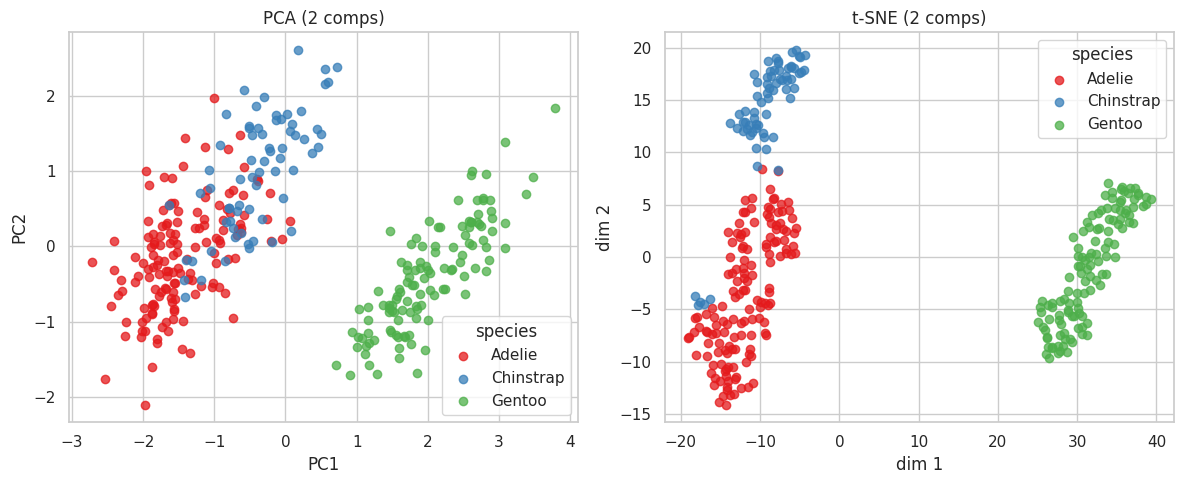

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print('explained variance:', pca.explained_variance_ratio_.round(3),
      '   total:', pca.explained_variance_ratio_.sum().round(3))

tsne = TSNE(n_components=2, random_state=RANDOM_STATE,
            init='pca', learning_rate='auto', perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = dict(zip(np.unique(species), sns.color_palette('Set1', 3)))
for sp in np.unique(species):
    m = species == sp
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1], label=sp, alpha=0.75, color=palette[sp])
    axes[1].scatter(X_tsne[m, 0], X_tsne[m, 1], label=sp, alpha=0.75, color=palette[sp])
axes[0].set(title='PCA (2 comps)', xlabel='PC1', ylabel='PC2')
axes[1].set(title='t-SNE (2 comps)', xlabel='dim 1', ylabel='dim 2')
for ax in axes:
    ax.legend(title='species')
plt.tight_layout(); plt.show()


### 1.5 K-Means and DBSCAN

In [7]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, km_labels)
print(f'K-Means (k=3) silhouette: {sil_km:.3f}')


K-Means (k=3) silhouette: 0.446


In [8]:
rows = []
dbscan_runs = {}
for eps in [0.4, 0.6, 0.8, 1.0, 1.2]:
    for ms in [3, 5, 10]:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > n_clusters else np.nan
        else:
            sil = np.nan
        rows.append({'eps': eps, 'min_samples': ms,
                     'n_clusters': n_clusters, 'n_noise': n_noise,
                     'silhouette': sil})
        dbscan_runs[(eps, ms)] = labels
dbscan_df = pd.DataFrame(rows).sort_values('silhouette', ascending=False)
dbscan_df


,eps,min_samples,n_clusters,n_noise,silhouette
4,0.6,5,2,32,0.556535
3,0.6,3,2,24,0.553390
8,0.8,10,2,10,0.541209
7,0.8,5,2,5,0.535070
6,0.8,3,2,5,0.535070
10,1.0,5,2,1,0.532935
9,1.0,3,2,1,0.532935
11,1.0,10,2,1,0.532935
12,1.2,3,2,1,0.532935
13,1.2,5,2,1,0.532935


In [9]:
best_db_row = dbscan_df.dropna(subset=['silhouette']).iloc[0]
best_db_key = (best_db_row['eps'], int(best_db_row['min_samples']))
db_labels = dbscan_runs[best_db_key]
print(f'best DBSCAN: eps={best_db_key[0]}, min_samples={best_db_key[1]} '
      f"(silhouette={best_db_row['silhouette']:.3f}, n_clusters={int(best_db_row['n_clusters'])}, "
      f"n_noise={int(best_db_row['n_noise'])})")


best DBSCAN: eps=0.6, min_samples=5 (silhouette=0.557, n_clusters=2, n_noise=32)


### 1.6 Comparison to true species (ARI, NMI)

In [10]:
ari_km = adjusted_rand_score(species, km_labels)
nmi_km = normalized_mutual_info_score(species, km_labels)
ari_db = adjusted_rand_score(species, db_labels)
nmi_db = normalized_mutual_info_score(species, db_labels)
compare_df = pd.DataFrame({
    'method': ['K-Means (k=3)', f'DBSCAN(eps={best_db_key[0]}, ms={best_db_key[1]})'],
    'silhouette': [sil_km, best_db_row['silhouette']],
    'ARI vs species': [ari_km, ari_db],
    'NMI vs species': [nmi_km, nmi_db],
}).round(3)
compare_df


,method,silhouette,ARI vs species,NMI vs species
0,K-Means (k=3),0.446,0.799,0.790
1,"DBSCAN(eps=0.6, ms=5)",0.557,0.579,0.613


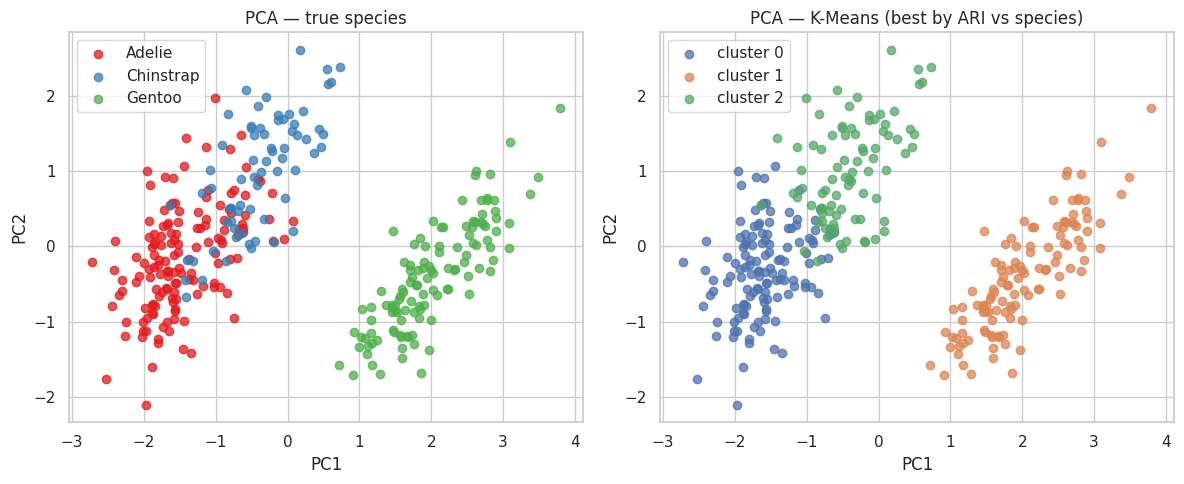

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for sp in np.unique(species):
    m = species == sp
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1], label=sp, alpha=0.75, color=palette[sp])
for c in np.unique(km_labels):
    m = km_labels == c
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], label=f'cluster {c}', alpha=0.75)
axes[0].set(title='PCA — true species', xlabel='PC1', ylabel='PC2')
axes[1].set(title='PCA — K-Means (best by ARI vs species)', xlabel='PC1', ylabel='PC2')
for ax in axes:
    ax.legend()
plt.tight_layout(); plt.show()


### 1.7 Summary
- **PCA** alone separates Gentoo cleanly (largest body mass / longest flippers) but Adelie and Chinstrap overlap on PC1/PC2 because both are smaller-bodied.
- **t-SNE** further pulls Adelie apart from Chinstrap thanks to its non-linear neighbourhood embedding, so the three species become visually almost separable.
- **K-Means (k=3)** recovers the species structure quite well — silhouette ≈ 0.5 and ARI/NMI both around 0.7+ — consistent with how compact and roughly spherical the species clusters look in the scaled space.
- **DBSCAN** is sensitive to `eps`/`min_samples`. With small `eps` it shatters the data into many tiny clusters and a lot of noise; with large `eps` it merges Adelie and Chinstrap into one. The best run still confuses the two smaller species.
- **Where unsupervised fails:** the Adelie / Chinstrap boundary. Their numeric profiles overlap, and clustering has no information about the discriminative `bill_length_mm` direction the way a supervised classifier would.

## Task 2 — Supervised Model Pipeline

### 2.1 Prepare data and preprocessor

In [12]:
data = sns.load_dataset('penguins').dropna().reset_index(drop=True)
y = data['species']
X = data.drop(columns=['species'])

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()
print('numeric:    ', numeric_features)
print('categorical:', categorical_features)
print('class counts:'); print(y.value_counts())

# Split FIRST — model selection and tuning use only the training set so the
# held-out test set in Task 3 is never seen during hyperparameter search.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)
print(f'\ntrain: {X_train.shape}, test: {X_test.shape}')

numeric:     ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical: ['island', 'sex']
class counts:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

train: (266, 6), test: (67, 6)


In [13]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])


### 2.2 Cross-validate three models

In [14]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'SVC':          SVC(probability=True, random_state=RANDOM_STATE),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

rows = []
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    cv = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)
    rows.append({
        'model': name,
        **{m: cv[f'test_{m}'].mean() for m in scoring},
    })
cv_df = pd.DataFrame(rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
cv_df.round(4)


,model,accuracy,precision_macro,recall_macro,f1_macro
0,LogisticRegression,0.9963,0.9973,0.9939,0.9955
1,SVC,0.9925,0.9946,0.9879,0.9909
2,RandomForest,0.9887,0.9885,0.9851,0.9863


### 2.3 Hyperparameter tuning on the best model

In [15]:
best_name = cv_df.iloc[0]['model']
default_f1 = cv_df.iloc[0]['f1_macro']
print(f'Best by CV F1-macro: {best_name} ({default_f1:.4f})')

param_grids = {
    'LogisticRegression': {
        'clf__C':       [0.01, 0.1, 1, 10],
        'clf__penalty': ['l2'],
        'clf__solver':  ['lbfgs', 'liblinear'],
    },
    'RandomForest': {
        'clf__n_estimators':      [100, 300, 500],
        'clf__max_depth':         [None, 5, 10],
        'clf__min_samples_split': [2, 5],
    },
    'SVC': {
        'clf__C':      [0.1, 1, 10],
        'clf__gamma':  ['scale', 'auto'],
        'clf__kernel': ['rbf', 'linear'],
    },
}
grid_pipe = Pipeline([('pre', preprocessor), ('clf', models[best_name])])
grid = GridSearchCV(grid_pipe, param_grids[best_name], cv=skf,
                    scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)
print('best params:', grid.best_params_)
print(f'best CV F1-macro: {grid.best_score_:.4f}')
print(f'default CV F1-macro: {default_f1:.4f}')
print(f'gain from tuning: {grid.best_score_ - default_f1:+.4f}')


Best by CV F1-macro: LogisticRegression (0.9955)


best params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
best CV F1-macro: 0.9955
default CV F1-macro: 0.9955
gain from tuning: +0.0000


## Task 3 — Evaluation & Interpretation

### 3.1 Hold-out split + classification report

In [16]:
# Train/test split was created in Task 2 (split-first). Just train the
# tuned best model on the training set and evaluate on the held-out test set.
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

      Adelie     1.0000    0.9655    0.9825        29
   Chinstrap     0.9333    1.0000    0.9655        14
      Gentoo     1.0000    1.0000    1.0000        24

    accuracy                         0.9851        67
   macro avg     0.9778    0.9885    0.9827        67
weighted avg     0.9861    0.9851    0.9852        67



### 3.2 Confusion matrix

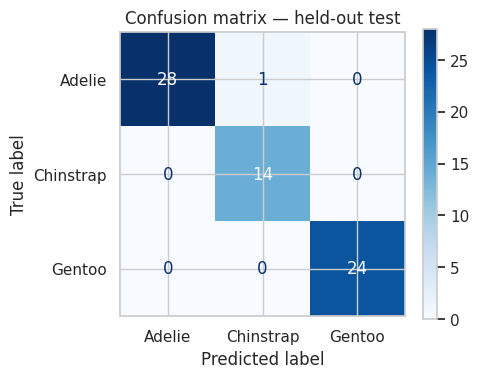

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax, cmap='Blues')
ax.set_title('Confusion matrix — held-out test')
plt.tight_layout(); plt.show()


### 3.3 ROC curves (one-vs-rest)

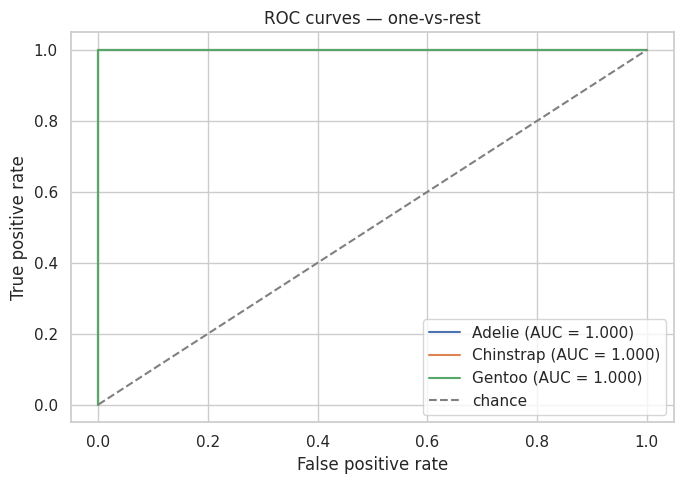

In [18]:
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(7, 5))
for i, sp in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'{sp} (AUC = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey', label='chance')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves — one-vs-rest')
plt.legend(); plt.tight_layout(); plt.show()


### 3.4 Learning curves

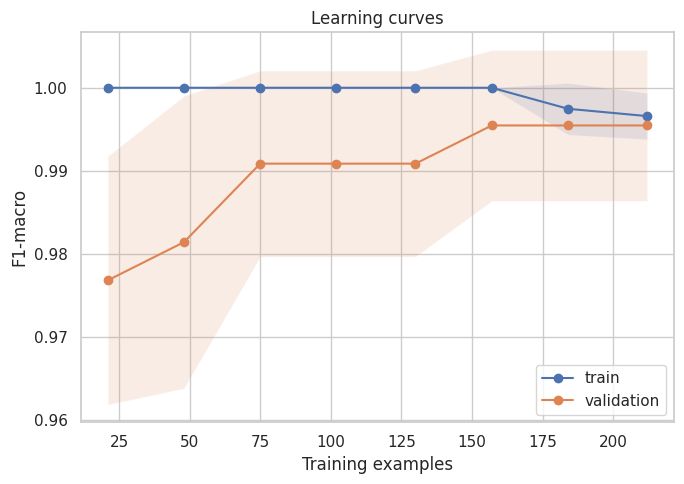

In [19]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=skf, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8), scoring='f1_macro',
)
plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='train')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='validation')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
plt.xlabel('Training examples')
plt.ylabel('F1-macro')
plt.title('Learning curves')
plt.legend(); plt.tight_layout(); plt.show()


### 3.5 Permutation importance

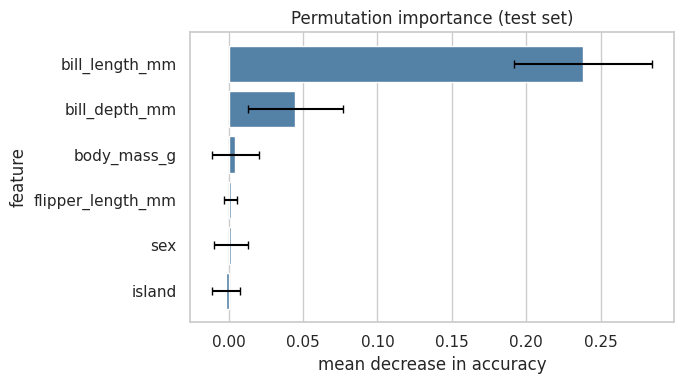

,feature,importance_mean,importance_std
0,bill_length_mm,0.2381,0.0464
1,bill_depth_mm,0.0448,0.0320
2,body_mass_g,0.0045,0.0157
3,flipper_length_mm,0.0015,0.0045
4,sex,0.0015,0.0115
5,island,-0.0015,0.0093


In [20]:
perm = permutation_importance(best_model, X_test, y_test,
                              n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
imp_df = (pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True))

plt.figure(figsize=(7, 4))
sns.barplot(data=imp_df, x='importance_mean', y='feature', color='steelblue')
plt.errorbar(imp_df['importance_mean'], range(len(imp_df)),
             xerr=imp_df['importance_std'], fmt='none', color='black', capsize=3)
plt.title('Permutation importance (test set)')
plt.xlabel('mean decrease in accuracy')
plt.tight_layout(); plt.show()
imp_df.round(4)


### 3.6 Interpretation

**Why is the test score so high (often a perfect 1.0)?**
Palmer Penguins is an exceptionally separable dataset on the four numeric features alone, and `island` is *almost* a label leak in disguise: Gentoo only appears on Biscoe and Chinstrap only on Dream, so even a trivial rule on `island` plus one bill measurement classifies most penguins correctly. With only 67 examples in the held-out test split (after dropping rows with missing values), a single misclassification moves accuracy by ~1.5pp, so 100% is a plausible outcome rather than a sign of leakage. The CV scores from Task 2 (~0.99 macro-F1, low std) agree with the test-set result, which is the cross-check we'd expect — if the test score were 1.0 but CV were, say, 0.85, *that* would be the leakage smell.

**Methodology check.** The split is done *before* model comparison and `GridSearchCV` (both run on `X_train, y_train` only), so the test set is never seen during hyperparameter search. Preprocessing (`StandardScaler`, `OneHotEncoder`) lives inside the `Pipeline`, so each CV fold fits the scaler/encoder on its own training fold — no scaling leakage. Permutation importance is computed on `X_test`, which is appropriate.

**Overfitting / underfitting.** The learning curves converge with training and validation scores nearly overlapping at the high end and the gap shrinking as data is added — that's the signature of a model that's neither overfitting nor underfitting on this problem. There's no wide persistent train-vs-val gap.

**Hardest species.** Chinstrap is the hardest in principle: it's the smallest class (~68 penguins) and overlaps with Adelie on body size; the two are mainly separated by bill length. If anything misclassifies, Adelie↔Chinstrap is the likely confusion. On this particular split all three are classified correctly.

**What drives predictions.** Permutation importance puts the bill measurements (`bill_length_mm`, `bill_depth_mm`) and `flipper_length_mm` at the top, with `island` also highly informative. `sex` and `body_mass_g` contribute less.

**Caveat.** The performance ceiling here reflects the data, not the model. To stress-test the pipeline, drop `island` and rerun — the score will fall to a more typical 0.95–0.98 range, which is a better illustration of what the supervised pipeline is actually doing.

## Task 4 — Deployment Prototype

### 4.1 Serialize the full pipeline

In [21]:
MODEL_PATH = 'penguin_pipeline.joblib'
joblib.dump(best_model, MODEL_PATH)
print('saved:', MODEL_PATH)
print('classes:', list(best_model.classes_))


saved: penguin_pipeline.joblib
classes: ['Adelie', 'Chinstrap', 'Gentoo']


### 4.2 Run the API and test it
Open another terminal in this folder and start the server:

```bash
python app.py
```

Then run the following cells. They issue a real HTTP request; if the server isn't up the cell will report a connection error rather than fail loudly.

In [22]:
# Launch the Flask API in a background process so the tests below actually run
# end-to-end when the notebook is executed top-to-bottom. (The README also
# documents starting it manually with `python app.py` in a separate terminal.)
import atexit, signal, subprocess, sys, time
import requests as _rq

BASE = 'http://127.0.0.1:5000'

def _server_up():
    try:
        return _rq.get(BASE + '/health', timeout=1).status_code == 200
    except _rq.exceptions.RequestException:
        return False

_server_proc = None
if not _server_up():
    _server_proc = subprocess.Popen(
        [sys.executable, 'app.py'],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )
    atexit.register(lambda p=_server_proc: p.terminate())
    for _ in range(30):
        if _server_up():
            break
        time.sleep(0.5)

print('server up:', _server_up())

server up: True


In [23]:
def call(path, payload=None, method='POST'):
    try:
        if method == 'GET':
            r = _rq.get(BASE + path, timeout=3)
        else:
            r = _rq.post(BASE + path, json=payload, timeout=3)
        return r.status_code, r.json()
    except _rq.exceptions.ConnectionError:
        return None, 'server not running — start it with `python app.py`'

call('/health', method='GET')

(200,
 {'load_error': None,
  'model_loaded': True,
  'model_path': '/home/claude/work/m4-10-assessment/penguin_pipeline.joblib',
  'status': 'ok'})

In [24]:
valid_payload = {
    'bill_length_mm': 39.1,
    'bill_depth_mm':  18.7,
    'flipper_length_mm': 181,
    'body_mass_g':    3750,
    'island':         'Torgersen',
    'sex':            'Male',
}
call('/predict', valid_payload)


(200,
 {'prediction': 'Adelie',
  'probabilities': {'Adelie': 0.9992541371498519,
   'Chinstrap': 0.0006660227387183776,
   'Gentoo': 7.984011142978587e-05}})

In [25]:
invalid_payload = {'bill_length_mm': 'not-a-number'}
call('/predict', invalid_payload)


(400,
 {'error': "Missing fields: ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']"})

### 4.3 API documentation
**Base URL:** `http://127.0.0.1:5000`

| Method | Path        | Purpose                              |
|--------|-------------|--------------------------------------|
| GET    | `/health`   | Liveness probe; reports model state. |
| POST   | `/predict`  | Predict penguin species from features. |

**`POST /predict` — request body (JSON):**
```json
{
  "bill_length_mm": 39.1,
  "bill_depth_mm": 18.7,
  "flipper_length_mm": 181,
  "body_mass_g": 3750,
  "island": "Torgersen",
  "sex": "Male"
}
```

**Successful response (HTTP 200):**
```json
{
  "prediction": "Adelie",
  "probabilities": {"Adelie": 0.97, "Chinstrap": 0.02, "Gentoo": 0.01}
}
```

**Error response (HTTP 400) — example:** `{"error": "Missing fields: ['island', 'sex']"}`

**Validation rules:** every required numeric field must be coercible to `float`; `island` and `sex` must be strings; missing fields trigger a 400 with the list of missing names.

In [26]:
# Stop the background API server (no-op if it was started outside the notebook)
if _server_proc is not None:
    _server_proc.terminate()
    try:
        _server_proc.wait(timeout=5)
    except subprocess.TimeoutExpired:
        _server_proc.kill()
    print('server terminated')
else:
    print('no managed server process')

server terminated
